## Import

In [1]:
import collections
import pathlib

import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, losses, utils
from tensorflow.keras.layers import TextVectorization
from pathlib import Path

import tensorflow_datasets as tfds
import tensorflow_text as tf_text

## Functions

In [2]:
"""เป็นฟังก์ชันที่ใช้ในการแสดงคำในประโยค เป็นตัวเลข ที่ทำได้เพราะว่าเราเรียกใช้ int_vectorize_layer ที่ใช้ในการ
แปลงคำเป็นตัวเลข แล้วฟังก์ชันใน cell นี้อะ มันคือแบบการแสดงผลของคำที่แปลงเป็นตัวเลขแล้ว"""

def int_vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return int_vectorize_layer(text), label

In [3]:

"""
- cache: เก็บข้อมูลเอาไว้ในหน่วยความจำเพื่อให้สามารถเข้าถึงข้อมูลได้เร็วขึ้น เพราะเก็บเอาไว้ใน cache แล้ว
- prefetch: เป็นการดึง batch ถัดไปเข้ามาล่วงหน้า เพื่อให้การประมวลผลเร็วขึ้น โดยไม่ต้องรอให้ batch ปัจจุบันเสร็จสิ้น
"""
def configure_dataset(dataset):
    return dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [4]:
def plot_graphs(history, metric):
    plt.plot(history.history[metric])
    plt.plot(history.history['val_'+metric], '')
    plt.xlabel('Epochs')
    plt.ylabel(metric)
    plt.legend([metric, 'val_'+metric])

## Download and explore the dataset
- keras.utils.text_dataset_from_directory: for loading text-file examples.
- keras.layers.TextVectorization: for converting strings to token indices.

In [5]:
data_url = 'https://storage.googleapis.com/download.tensorflow.org/data/stack_overflow_16k.tar.gz'

dataset_dir = utils.get_file(
    origin=data_url,
    untar=True,
    cache_dir='stack_overflow',
    cache_subdir='')

dataset_dir = pathlib.Path(dataset_dir).parent

In [6]:
list(dataset_dir.iterdir())

[WindowsPath('/tmp/.keras/README.md'),
 WindowsPath('/tmp/.keras/stack_overflow_16k.tar.gz'),
 WindowsPath('/tmp/.keras/test'),
 WindowsPath('/tmp/.keras/train')]

In [7]:
for path in dataset_dir.iterdir():
    print(path.absolute())

d:\tmp\.keras\README.md
d:\tmp\.keras\stack_overflow_16k.tar.gz
d:\tmp\.keras\test
d:\tmp\.keras\train


In [8]:
train_dir = Path('../tmp/.keras/train')
list(train_dir.iterdir())

[WindowsPath('../tmp/.keras/train/csharp'),
 WindowsPath('../tmp/.keras/train/java'),
 WindowsPath('../tmp/.keras/train/javascript'),
 WindowsPath('../tmp/.keras/train/python')]

In [9]:
sample_file = train_dir / 'python/0.txt'

with open(sample_file) as f:
    print(f.read())

"is it legal to define two methods with the same name but different returning types? i've written a piece of code to determine a typical palindrome string. i did this by the definition of a reverse() method returning a string. i also eager to have the same method, but in the void form, because of some future needs..as i add the latter to the code, the valid output will become invalid..so, the question is that is it legal to define two methods with the same name but different returning types?.if not, please let me know how to write this code with the void-type method...class detector(object):.    def __init__(self,string):.        self.string = string..    forbidden = (' ','!','?','.','-','_','&amp;','%',""#"","","")..    def eliminator(self):.        for item in self.forbidden:.            if item in self.string:.                self.string = self.string.replace(item,"""")..    def reverse(self):.        return self.string[::-1]            ..    #def reverse(self):.    #    self.string

## Training Set

In [10]:
batch_size = 32
seed = 42

""" โค๊ดชุดนี้บอกว่า เราจะเอาข้อมูลจาก train_dir มาใช้สำหรับการเทรนโมเดล 80 เปอร์เซนต์ คำว่า subset คือบอกว่า
ข้อมูลที่เอามา จะอยู่ใน subset ที่ชื่อว่า train """
raw_train_ds = utils.text_dataset_from_directory(
    train_dir,
    batch_size=batch_size,
    validation_split=0.2,
    subset='training',
    seed=seed,
    shuffle=True
)

Found 8000 files belonging to 4 classes.
Using 6400 files for training.


In [11]:
"""take(1): หมายความว่า เอา batch แรกออกมาแสดงผล"""
i = 0

for text_batch, label_batch in raw_train_ds.take(1):
    for i in range(10):
        print("Question: ", text_batch.numpy()[i])
        print("Label: ", label_batch.numpy()[i])

Question:  b'"my tester is going to the wrong constructor i am new to programming so if i ask a question that can be easily fixed, please forgive me. my program has a tester class with a main. when i send that to my regularpolygon class, it sends it to the wrong constructor. i have two constructors. 1 without perameters..public regularpolygon().    {.       mynumsides = 5;.       mysidelength = 30;.    }//end default constructor...and my second, with perameters. ..public regularpolygon(int numsides, double sidelength).    {.        mynumsides = numsides;.        mysidelength = sidelength;.    }// end constructor...in my tester class i have these two lines:..regularpolygon shape = new regularpolygon(numsides, sidelength);.        shape.menu();...numsides and sidelength were declared and initialized earlier in the testing class...so what i want to happen, is the tester class sends numsides and sidelength to the second constructor and use it in that class. but it only uses the default con

In [12]:
""" โขว์ Label ทั้งหมดที่มีใน dataset """
i = 0

for i, label in enumerate(raw_train_ds.class_names):
    print("Label", i, "corresponds to", label)

Label 0 corresponds to csharp
Label 1 corresponds to java
Label 2 corresponds to javascript
Label 3 corresponds to python


## Validation Set

In [13]:
raw_val_ds = utils.text_dataset_from_directory(
    train_dir,
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation',
    seed=seed,
    shuffle=True
)

Found 8000 files belonging to 4 classes.
Using 1600 files for validation.


## Test Set

In [14]:
test_dir = Path('../tmp/.keras/test')

raw_test_ds = utils.text_dataset_from_directory(
    test_dir,
    batch_size=batch_size
)

Found 8000 files belonging to 4 classes.


In [15]:
i = 0
for text_batch, label_batch in raw_test_ds.take(1):
    for i in range(3):
        print("Label:", label_batch.numpy()[i],"Question:", text_batch.numpy()[i])

Label: 3 Question: b'"cannot get a new instance i wrote the following blank code...i was expecting a new tmp instance in every loop, so every time i print tmp.c, i should get ""[1]""...why is this happening?..class f():.    c = [].    def __init__(self):.        self.c.append(1)..for i in range(5):.    tmp = f().    print(tmp.c).    print(tmp)...the output is:..&lt;__main__.f object at 0x7f7566b0b7f0&gt;.[1, 1].&lt;__main__.f object at 0x7f7566b0b668&gt;.[1, 1, 1].&lt;__main__.f object at 0x7f7566b0b828&gt;.[1, 1, 1, 1].&lt;__main__.f object at 0x7f7566b0b668&gt;.[1, 1, 1, 1, 1].&lt;__main__.f object at 0x7f7566b0b828&gt;"\n'
Label: 0 Question: b'"blank code to handle different classes with same method names let\'s say you have two different blank classes a and b that while not deriving from the same base class do share some of the same names for methods. for example, both classes have a connect and a disconnect method, as well as several others. i want to be able to write code once th

## Prepare data for training
    TextVectorization คือ Layer สำหรับเตรียมข้อความให้พร้อมใช้งานในโมเดล TensorFlow หรือพูดง่าย ๆ ก็คือ:
    เอาข้อความ (Text) → แปลงเป็นตัวเลข (Numbers) เพื่อให้โมเดลเข้าใจและนำไปใช้เรียนรู้ต่อได้

    หน้าที่หลักๆ ของ TextVectorization มีดังนี้ 
    - การจัดคำ หมายถึง การลบเครื่องหมายต่างๆ และองค์ประกอบของ HTML ออกไปให้เหลือแต่ Text
    - Tokenization หมายถึง การแยกสตริงออกเป็น Token เช่น จากประโยคให้กลายเป็น คำ ซึ่งแต่ละคำอาจจะแทนด้วย Token
    - Vectoriztation หมายถึง การแปลง Token เหล่านั้นเป็นตัวเลขเฉพาะเพื่อให้ โมเดล เรียนรู้ได้

    
    parameters's TextVectorization
    tf.keras.layers.TextVectorization(
    max_tokens=None,
    standardize='lower_and_strip_punctuation',
    split='whitespace',
    ngrams=None,
    output_mode='int',
    output_sequence_length=None,
    pad_to_max_tokens=False,
    vocabulary=None,
    idf_weights=None,
    sparse=False,
    ragged=False,
    encoding='utf-8',
    name=None,
    **kwargs
    )

In [16]:
VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 250

int_vectorize_layer = TextVectorization(
    max_tokens=VOCAB_SIZE,
    standardize='lower_and_strip_punctuation',
    split='whitespace',
    output_mode='int',
    output_sequence_length=MAX_SEQUENCE_LENGTH
)

In [17]:
""" เราแปลงคำเป็นตัวเลขและ โดยใช้ TextVectorization layer ต่อมาคือ คำที่เราแปลงอะ 
โมเดลยังไม่รู้จักคำเหล่านั้นเลยว่าจะใช้งานยังไง เราเลยต้องการที่จะใช้ .adapt() เพื่อให้โมเดลรู้จักคำเหล่านั้นก่อนล่วงหน้า
ก่อนเอาไปประมวลผล """

train_text = raw_train_ds.map(lambda text, label: text)
int_vectorize_layer.adapt(train_text)

In [18]:
""" แสดงตัวอย่างประโยค """
text_batch, label_batch = next(iter(raw_train_ds))
first_question, label = text_batch[0], label_batch[0]
print("Question: ", first_question)
print("Label: ", label)

Question:  tf.Tensor(b'"set blank to quit on exception? i\'m using blank 3..i\'ve been looking around for an answer to this, but i haven\'t found it yet. basically, i\'m running several blank scripts into a game engine, and each script has its own entry point...i\'d rather not add try: except blocks through all of my code, so i was wondering if it\'s at all possible to tell blank to quit (or perhaps assign a custom function to that ""callback"") on finding its first error, regardless of where or what it found? ..currently, the game engine will continue after finding and hitting an error, making it more difficult than necessary to diagnose issues since running into one error may make a subsequent script not work (as it relies on variables that the error-ing script set, for example). any ideas? ..i know that i could redirect the console to a file to allow for easier scrolling, but just capturing the first error and stopping the game prematurely would be really useful...okay, a couple of 

In [19]:
print("'int' vectorized question: ",
      int_vectorize_text(first_question, label)[0])

'int' vectorized question:  tf.Tensor(
[[ 107   16    4 1138   38  184   52   47   16    1  215  416  518   12
    32  181    4   13   26    3 1414  227   11  894  627   52  309  718
    16 1272  100    5  244 1826    8  119  223   95   96  657  858    1
   797   20  125  117  559 2280  194   73    9   23   30   49    3  114
   566   10   96   59   73  206    4  412   16    4 1138   45 1669  600
     5  696   37    4   14  850   38  966   96   98   65 2373    9  132
    45   55   11  227  403    2  244 1826   72  534  156  966    8 7799
    32   65  469   11  182 2332  198 1460    4    1 1093  447  309  100
    71   65  454  109    5 3554  223   20  139   36   11 9038   38  233
    14    2    1  223  107   12  137   76  778    3  103   14    3  177
  1852    2  332    4    5   39    4  787   12 1319 3573   26  106    1
     2   98   65    8 2900    2  244    1   69   33  336    1    5 1758
     9 1157 2528    9  568  729   12    1    4  321   13    2 1826   52
    47    2    1  244 182

## แสดงตัวอย่างการใช้ index ในการแสดงคำนั้นๆ

In [20]:
print("1444 ---> ", int_vectorize_layer.get_vocabulary()[1444])
print("568 ---> ", int_vectorize_layer.get_vocabulary()[568])
print("Vocalabulary size: {}".format(len(int_vectorize_layer.get_vocabulary())))

1444 --->  driver
568 --->  info
Vocalabulary size: 10000


In [21]:
"""
- raw_train/val/test_ds: เป็นชุดข้อมูลดิบ กล่าวคือชุดข้อมูลที่เป็น string ล้วนๆ
- int_vectorize_text: แปลงข้อความเป็นลำดับของตัวเลข (token ids)
- raw_train/val/test_ds.map(int_vectorize_text): แปลงชุดข้อมูลดิบแล้ว map คำให้ตรงกับตัวเลขนั้นๆ ที่ int_vectorize_text
ทำการแปลงคำเป็นตัวเลขเอาไว้ ซึ่งลำดับของคำยังเหมือนเดิม
"""
int_train_ds = raw_train_ds.map(int_vectorize_text)
int_val_ds = raw_val_ds.map(int_vectorize_text)
int_test_ds = raw_test_ds.map(int_vectorize_text)

In [22]:
""" AUTOTUNE เป็นการตั้งค่าที่ช่วยให้ TensorFlow เลือกค่าที่ดีที่สุดโดยอัตโนมัติ ซึ่งจะทำให้การทำงานใน pipeline นั้นมี
ประสิทธิภาพมากยิ่งขึ้น
"""
AUTOTUNE = tf.data.AUTOTUNE

int_train_ds = configure_dataset(int_train_ds)
int_val_ds = configure_dataset(int_val_ds)
int_test_ds = configure_dataset(int_test_ds)

## Training model

In [23]:
def create_model(vocab_size, num_labels):
  model = tf.keras.Sequential([
      layers.Embedding(vocab_size, 64, mask_zero=True),
      layers.Conv1D(128, 5, padding="same", activation="relu", strides=1),
      layers.GlobalMaxPooling1D(),
      layers.Dense(64, activation="relu"),
      layers.Dense(num_labels, activation="softmax")
  ])
  return model

### Create the model

In [24]:
model = create_model(vocab_size=VOCAB_SIZE + 1, num_labels=4)

### Model structure

In [25]:
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 64)          640064    
                                                                 
 conv1d (Conv1D)             (None, None, 128)         41088     
                                                                 
 global_max_pooling1d (Globa  (None, 128)              0         
 lMaxPooling1D)                                                  
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dense_1 (Dense)             (None, 4)                 260       
                                                                 
Total params: 689,668
Trainable params: 689,668
Non-trainable params: 0
__________________________________________________

### Setting hyperparameters

In [26]:
""" from_logits=True หมายความว่า ค่า output ที่ส่งเข้ามาจากโมเดล ยังไม่ผ่าน softmax นะ 
ช่วยคำนวณ loss ให้หน่อยโดย รวมการทำ softmax ไปในตัวเลย ในกรณีที่เรายังไม่ได้กำหนด activation function 
ใน layer สุดท้าย ถ้าใส่ activation='softmax' ใน layer สุดท้ายแล้ว ก็เปลี่ยนเป็น = false ได้"""

lr_scheduler = tf.keras.optimizers.schedules.InverseTimeDecay(0.001, decay_rate=1e-6, decay_steps=1, staircase=False)
opt = tf.keras.optimizers.Adam(learning_rate=lr_scheduler)

model.compile(
    loss=losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=opt,
    metrics=['accuracy'],
)

### Training

In [27]:
print("Input dim of Embedding: ", len(int_vectorize_layer.get_vocabulary()))
print("Max token index in dataset: ")

for example, _ in int_train_ds.take(5):
    print(tf.reduce_max(example))


Input dim of Embedding:  10000
Max token index in dataset: 
tf.Tensor(9946, shape=(), dtype=int64)
tf.Tensor(9938, shape=(), dtype=int64)
tf.Tensor(9992, shape=(), dtype=int64)
tf.Tensor(9784, shape=(), dtype=int64)
tf.Tensor(9960, shape=(), dtype=int64)


In [28]:
history = model.fit(int_train_ds, batch_size=32, epochs=5, validation_data=int_val_ds)

Epoch 1/5
200/200 [==============================] - 6s 19ms/step - loss: 1.0170 - accuracy: 0.5406 - val_loss: 0.6130 - val_accuracy: 0.7538
Epoch 2/5
200/200 [==============================] - 1s 5ms/step - loss: 0.4878 - accuracy: 0.8084 - val_loss: 0.4786 - val_accuracy: 0.8175
Epoch 3/5
200/200 [==============================] - 1s 5ms/step - loss: 0.2372 - accuracy: 0.9291 - val_loss: 0.4868 - val_accuracy: 0.8306
Epoch 4/5
200/200 [==============================] - 1s 5ms/step - loss: 0.0831 - accuracy: 0.9831 - val_loss: 0.5280 - val_accuracy: 0.8263
Epoch 5/5
200/200 [==============================] - 1s 5ms/step - loss: 0.0209 - accuracy: 0.9981 - val_loss: 0.5958 - val_accuracy: 0.8219


### Evaluate

In [29]:
test_loss, test_accuracy = model.evaluate(int_test_ds, verbose=1)

print(f"Test Loss: {test_loss:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")

250/250 [==============================] - 8s 33ms/step - loss: 0.6210 - accuracy: 0.8073
Test Loss: 0.621
Test Accuracy: 0.807


## Reported

### Visualized

(0.0, 1.0667808329686523)

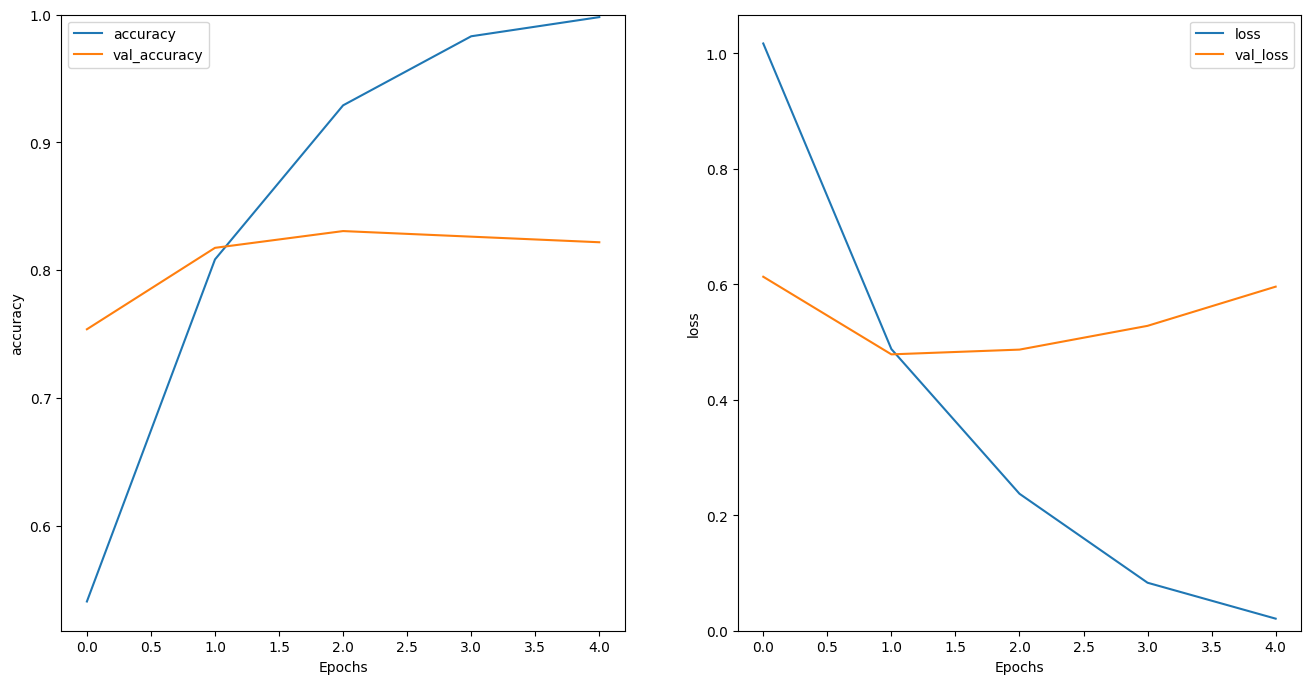

In [30]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')
plt.ylim(0, None)

### Classification Report

In [31]:
from sklearn.metrics import classification_report, confusion_matrix

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
y_true = np.concatenate([label_batch.numpy() for _, label_batch in int_test_ds], axis=0)
y_pred = np.argmax(model.predict(int_test_ds), axis=1)

250/250 [==============================] - 1s 2ms/step


In [33]:
"""Confusion Matrix"""

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Confusion Matrix:
[[1362  375  134  129]
 [ 156 1632   74  138]
 [  83   84 1709  124]
 [  56   79  110 1755]]


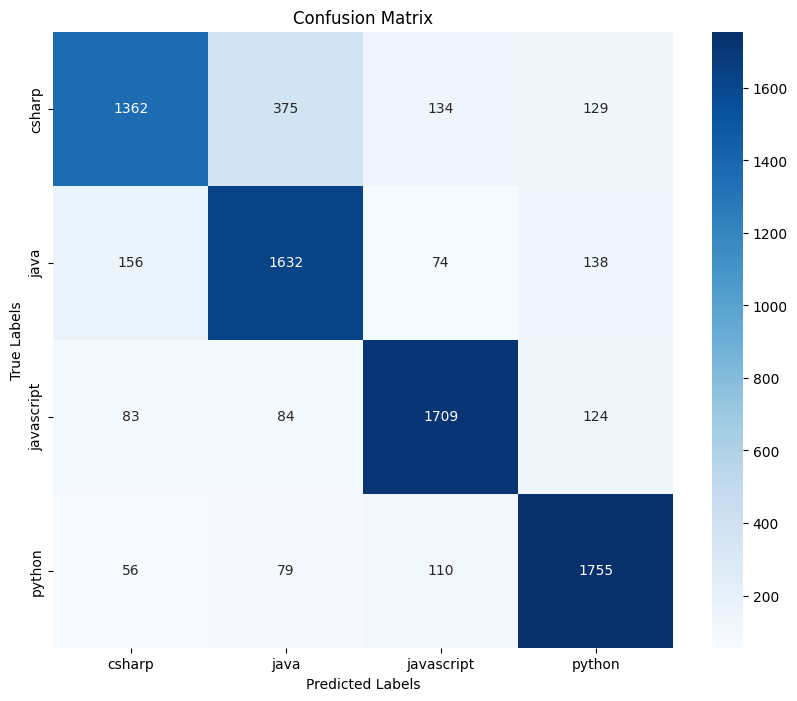

In [34]:
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=raw_train_ds.class_names, yticklabels=raw_train_ds.class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [35]:
"""Classification Report"""

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=raw_train_ds.class_names))

Classification Report:
              precision    recall  f1-score   support

      csharp       0.82      0.68      0.74      2000
        java       0.75      0.82      0.78      2000
  javascript       0.84      0.85      0.85      2000
      python       0.82      0.88      0.85      2000

    accuracy                           0.81      8000
   macro avg       0.81      0.81      0.81      8000
weighted avg       0.81      0.81      0.81      8000



## Export Model

In [36]:
export_model = tf.keras.Sequential([
    int_vectorize_layer,
    model,
    layers.Activation('softmax')
])

export_model.compile(
    loss=losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=opt,
    metrics=['accuracy'],
)

# Test it with 'raw_test_ds', which yields raw strings
loss, accuracy = export_model.evaluate(raw_test_ds, verbose=1)
print(f"Test Accuracy: {accuracy:.3f}")
print(f"Test Loss: {loss:.3f}")

250/250 [==============================] - 2s 6ms/step - loss: 0.9324 - accuracy: 0.8073
Test Accuracy: 0.807
Test Loss: 0.932


## Predict Model

In [37]:
def get_string_labels(predicted_scores_batch):
    predicted_int_labels = tf.argmax(predicted_scores_batch, axis=1)
    predicted_labels = tf.gather(raw_train_ds.class_names, predicted_int_labels)
    return predicted_labels

In [38]:
inputs = [
    "how do I extract keys from a dict into a list?", # 'python'
    "debug public static void main(string[] args) {...}", # 'java'
]

predicted_scores = export_model.predict(inputs)
predicted_labels = get_string_labels(predicted_scores)

for input, label in zip(inputs, predicted_labels):
    print("Question: ", input)
    print("Predicted label: ", label.numpy())

1/1 [==============================] - 0s 111ms/step
Question:  how do I extract keys from a dict into a list?
Predicted label:  b'python'
Question:  debug public static void main(string[] args) {...}
Predicted label:  b'java'
